## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013


# Avance 3. Baseline (Modelo de Referencia)




## Índice — Baseline

18. **Justificación del Algoritmo Baseline**  
    - 18.1 Análisis del Tipo de Problema  
    - 18.2 Selección del Algoritmo: Regresión Logística  

19. **Baseline — Comparación de las 4 Estrategias de Feature Engineering**  
    - 19.1 Preparación de los Datasets
    - 19.2 Entrenamiento con Regresión Logística
    - 19.3 Comparación y Diagnóstico

20. **Análisis de Características Importantes**  
    - 20.1 Coeficientes por estrategia  
    - 20.2 Visualización de las Características

21. **Métricas de Evaluación**  
    - 21.1 Justificación   
    - 21.2 Matrices de Confusión y Reporte de Clasificación 

22. **Análisis de Sub/Sobreajuste**  

23. **Conclusiones — Fase de Modelado Baseline (CRISP-ML)**  
    - 23.1 Selección de Estrategia 
    - 23.2 Siguientes Pasos (CRISP-ML)  

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importaciones Baseline
from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, learning_curve)
from sklearn.metrics        import (classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay,
                                    roc_auc_score, roc_curve,
                                    balanced_accuracy_score, f1_score,
                                    precision_score, recall_score,
                                    average_precision_score,
                                    PrecisionRecallDisplay)
from sklearn.pipeline       import Pipeline

print('Librerías de modelado cargadas correctamente.')

Librerías de modelado cargadas correctamente.


In [3]:
import os
DIR = "D:/Proyectos/Python/pi_psoriasis/data/features"
os.chdir(DIR)

In [4]:
#Inicialización de variables
COLORES = ['steelblue', 'tomato']

In [5]:
# Carga de datasets generados en la fase de FE
X_FULL_completo         = pd.read_csv('X_FULL_completo.csv', index_col=0)
X_CLUSTERING_completo   = pd.read_csv('X_CLUSTERING_completo.csv', index_col=0)
X_FILTER_MI_completo    = pd.read_csv('X_FILTER_MI_completo.csv', index_col=0)
X_FILTER_ANOVA_completo = pd.read_csv('X_FILTER_ANOVA_completo.csv', index_col=0)
y_temp                  = pd.read_csv('y_target.csv', index_col=0).squeeze()

---
## 18. Justificación del Algoritmo Baseline

### 18.1 Análisis del Tipo de Problema

| Dimensión | Característica del problema |
|---|---|
| **Tipo de datos** | Estructurados — tabla con variables de expresión génica (numéricas) y clínicas (categóricas) |
| **Tipo de tarea** | Clasificación binaria supervisada: Psoriasis (`1`) vs. Control sano (`0`) |
| **Tamaño del dataset** | Pocas muestras (docenas/centenas de pacientes), muchas características (cientos de sondas genómicas) → régimen *p >> n* |
| **Balance de clases** | Desbalanceado: 176 Sanos (29.38%) vs 423 con Psoriasis (70.61%) |
| **Interpretabilidad** | Alta: importa saber qué genes/variables clínicas discriminan la condición |
| **Línea base de referencia** | Clasificador aleatorio estratificado (DummyClassifier) |

### 18.2 Selección del Algoritmo: Regresión Logística

**Justificación frente a las alternativas:**

| Algoritmo | Pros | Contras para este caso |
|---|---|---|
| **Regresión Logística** ✅ | Simple, interpretable, coeficientes = importancia, funciona bien con regularización en *p >> n* | Asume linealidad; requiere escalado |
| Árbol de Decisión | Interpretable, no requiere escalado | Propenso a sobreajuste; no es un buen *baseline* |
| KNN | No paramétrico | Muy sensible a la dimensionalidad (*curse of dimensionality*) |
| SVM lineal | Bueno en *p >> n* | Menos interpretable; coeficientes no son probabilidades |
| Red neuronal | Alta capacidad | Requiere muchos datos; no apropiada como baseline |

La **Regresión Logística con regularización L2** (Ridge) es el baseline estándar para clasificación binaria con datos estructurados de alta dimensionalidad. Permite:
- Obtener probabilidades calibradas.
- Interpretar los coeficientes como importancia de características.
- Controlar el sobreajuste mediante el parámetro `C`.
- Manejar clases desbalanceadas (70.61% vs 29.38%) con `class_weight='balanced'`, sin necesidad de aplicar técnicas de sobremuestreo que pueden introducir variabilidad artificial.

## 19. Baseline — Comparación de las 4 Estrategias de Feature Engineering

**Objetivo:** Comparar el desempeño de las 4 estrategias (FULL, CLUSTERING, FILTER_MI, FILTER_ANOVA) usando Regresión Logística con manejo de clases desbalanceadas para seleccionar el dataset más relevante para el modelado.

**4 Casos Diagnósticos:**

- **CASO 1:** FILTER ≈ CLUSTERING ≈ FULL → Señal concentrada, sin redundancia relevante
- **CASO 2:** CLUSTERING ≈ FULL, FILTER peor → Variables débiles pero complementarias, descartar filtrado
- **CASO 3:** FILTER ≈ FULL, CLUSTERING peor → Señal en variables redundantes, descartar clustering
- **CASO 4:** FULL mejor que todos → Señal distribuida, ninguna estrategia de selección la captura completa

### 19.1 Preparación de los Datasets

In [6]:
# Diccionario con los 4 datasets
datasets = {
    'FULL'        : X_FULL_completo,
    'CLUSTERING'  : X_CLUSTERING_completo,
    'FILTER_MI'   : X_FILTER_MI_completo,
    'FILTER_ANOVA': X_FILTER_ANOVA_completo
}

print('📊 DATASETS PARA BASELINE:')
for nombre, X in datasets.items():
    print(f'   {nombre:15s}: {X.shape}')

print(f'\n   Target: {y_temp.shape}')
print(f'   Distribución: {y_temp.value_counts().to_dict()}')

📊 DATASETS PARA BASELINE:
   FULL           : (624, 339)
   CLUSTERING     : (624, 93)
   FILTER_MI      : (624, 19)
   FILTER_ANOVA   : (624, 19)

   Target: (624,)
   Distribución: {'Psoriasis': 449, 'Healthy': 175}


### 19.2 Entrenamiento con Regresión Logística

In [7]:
# Cell 13 — entrenar UNA vez y guardar modelos
resultados_baseline = {}
modelos_finales     = {}
splits_finales      = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, X in datasets.items():
    print(f'\n🔧 Entrenando estrategia: {nombre}')

    # CV para métricas
    modelo_cv = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    cv_results = cross_validate(modelo_cv, X, y_temp,
                                cv=cv,
                                scoring=['roc_auc', 'balanced_accuracy', 'f1_weighted'],
                                return_train_score=True)

    resultados_baseline[nombre] = {
        'AUC'         : cv_results['test_roc_auc'].mean(),
        'AUC_std'     : cv_results['test_roc_auc'].std(),
        'Balanced_Acc': cv_results['test_balanced_accuracy'].mean(),
        'F1'          : cv_results['test_f1_weighted'].mean(),
        'AUC_train'   : cv_results['train_roc_auc'].mean(),
    }

    # Modelo final — un solo split para visualizaciones
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    modelo_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    modelo_final.fit(X_train, y_train)

    modelos_finales[nombre] = modelo_final
    splits_finales[nombre]  = (X_train, X_test, y_train, y_test)

    print(f"   AUC: {resultados_baseline[nombre]['AUC']:.3f} ± {resultados_baseline[nombre]['AUC_std']:.3f} | "
          f"Balanced Acc: {resultados_baseline[nombre]['Balanced_Acc']:.3f} | "
          f"F1: {resultados_baseline[nombre]['F1']:.3f}")


🔧 Entrenando estrategia: FULL
   AUC: 0.972 ± 0.010 | Balanced Acc: 0.928 | F1: 0.930

🔧 Entrenando estrategia: CLUSTERING
   AUC: 0.944 ± 0.018 | Balanced Acc: 0.914 | F1: 0.906

🔧 Entrenando estrategia: FILTER_MI
   AUC: 0.914 ± 0.025 | Balanced Acc: 0.867 | F1: 0.852

🔧 Entrenando estrategia: FILTER_ANOVA
   AUC: 0.899 ± 0.019 | Balanced Acc: 0.845 | F1: 0.842


### 19.3 Comparación y Diagnóstico

📊 RESULTADOS DEL BASELINE:
  Estrategia  Variables      AUC  AUC_std  Balanced_Acc       F1
        FULL        339 0.972105 0.009857      0.928325 0.930480
  CLUSTERING         93 0.943546 0.018330      0.913990 0.906393
   FILTER_MI         19 0.913910 0.024620      0.866981 0.852236
FILTER_ANOVA         19 0.899103 0.018615      0.844562 0.841998


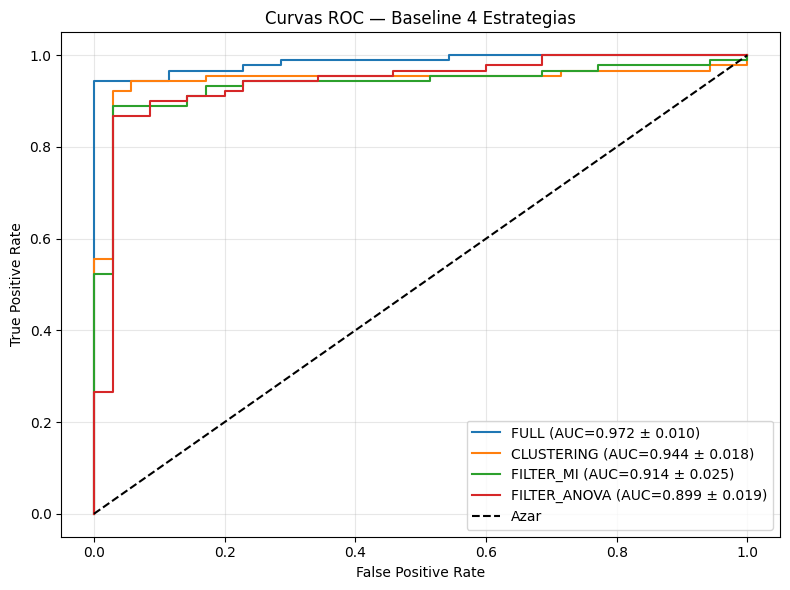


🔍 DIAGNÓSTICO PARA ESTRATEGIA FILTER:
   Estrategia         AUC   Balanced_Acc     F1
   ---------------------------------------------
   FILTER_MI        0.914          0.867  0.852
   FILTER_ANOVA     0.899          0.845  0.842

🔍 DIAGNÓSTICO GENERAL:
   CASO 4: FULL mejor que todos
      → Señal distribuida, ninguna estrategia de selección la captura completa


In [8]:
# Tabla de resultados
df_resultados = pd.DataFrame({
    'Estrategia'   : list(resultados_baseline.keys()),
    'Variables'    : [datasets[k].shape[1] for k in resultados_baseline.keys()],
    'AUC'          : [r['AUC'] for r in resultados_baseline.values()],
    'AUC_std'      : [r['AUC_std'] for r in resultados_baseline.values()],
    'Balanced_Acc' : [r['Balanced_Acc'] for r in resultados_baseline.values()],
    'F1'           : [r['F1'] for r in resultados_baseline.values()]
}).sort_values('AUC', ascending=False)

print('📊 RESULTADOS DEL BASELINE:')
print(df_resultados.to_string(index=False))

# Curvas ROC 
fig, ax = plt.subplots(figsize=(8, 6))

for nombre in datasets.keys():
    _, X_test, _, y_test = splits_finales[nombre]
    y_proba = modelos_finales[nombre].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label='Psoriasis')
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={resultados_baseline[nombre]['AUC']:.3f} ± {resultados_baseline[nombre]['AUC_std']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Baseline 4 Estrategias')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc_baseline.png', bbox_inches='tight', dpi=150)
plt.show()

# DIAGNÓSTICO AUTOMÁTICO
auc_full  = resultados_baseline['FULL']['AUC']
auc_clust = resultados_baseline['CLUSTERING']['AUC']
auc_mi    = resultados_baseline['FILTER_MI']['AUC']
auc_anova = resultados_baseline['FILTER_ANOVA']['AUC']
auc_filt  = max(auc_mi, auc_anova)
umbral    = 0.02 # Diferencia < 2% se considera similar

print('\n🔍 DIAGNÓSTICO PARA ESTRATEGIA FILTER:')
print(f"   {'Estrategia':<15} {'AUC':>6} {'Balanced_Acc':>14} {'F1':>6}")
print(f"   {'-'*45}")
for nombre in ['FILTER_MI', 'FILTER_ANOVA']:
    r = resultados_baseline[nombre]
    print(f"   {nombre:<15} {r['AUC']:>6.3f} {r['Balanced_Acc']:>14.3f} {r['F1']:>6.3f}")

print('\n🔍 DIAGNÓSTICO GENERAL:')
if (abs(auc_filt - auc_clust) < umbral and abs(auc_filt - auc_full) < umbral):
    print('   CASO 1: FILTER ≈ CLUSTERING ≈ FULL')
    print('      → Señal concentrada, pocas variables son suficientes')
elif (abs(auc_clust - auc_full) < umbral and auc_filt < auc_clust - umbral):
    print('   CASO 2: CLUSTERING ≈ FULL, FILTER peor')
    print('      → Variables débiles pero complementarias, descartar filtrado')
elif (abs(auc_filt - auc_full) < umbral and auc_clust < auc_full - umbral):
    print('   CASO 3: FILTER ≈ FULL, CLUSTERING peor')
    print('      → Señal en variables redundantes, descartar clustering')
elif (auc_full > max(auc_clust, auc_filt) + umbral):
    print('   CASO 4: FULL mejor que todos')
    print('      → Señal distribuida, ninguna estrategia de selección la captura completa')
else:
    print('   Resultados no concluyentes, requiere análisis detallado')

Baseline completado. Los resultados determinan qué estrategia usar en avances siguientes.

---
## 20. Análisis de Características Importantes

Con el baseline establecido, esta sección profundiza en el análisis de cada estrategia para comprender qué variables son más importantes, cómo se comportan las métricas en detalle, y qué estrategia seleccionar para avances posteriores.

### 20.1 Coeficientes por estrategia

Los coeficientes de la Regresión Logística entrenada en cada estrategia revelan qué variables son más discriminativas para clasificar Psoriasis vs. Healthy. Un coeficiente positivo indica que la variable favorece la clase *Psoriasis*; negativo, la clase *Healthy*.

Este análisis busca determinar cuales son las características más relevantes para el modelo generado. La magnitud absoluta del coeficiente refleja el peso relativo de cada variable en la decisión del modelo.

In [9]:
# Extraer coeficientes — reutilizando modelos_finales
importancias = {}

for nombre, X in datasets.items():
    modelo = modelos_finales[nombre]

    coef_df = pd.DataFrame({
        'Variable'   : X.columns,
        'Coeficiente': modelo.coef_[0],
        '|Coef|'     : abs(modelo.coef_[0])
    }).sort_values('|Coef|', ascending=False)

    importancias[nombre] = coef_df

    print(f'\n📊 Top 10 características — {nombre} ({len(X.columns)} variables):')
    print(coef_df.head(10).to_string(index=False))


📊 Top 10 características — FULL (339 variables):
                        Variable  Coeficiente   |Coef|
                          Sex_LE     1.871763 1.871763
STAT1 AFFX-HUMISGF3A/M97935_5_at     1.308617 1.308617
                CD86 205686_s_at    -1.149214 1.149214
                TAP2 204769_s_at     1.087159 1.087159
 DEFB103A /// DEFB103B 224239_at     1.082936 1.082936
               VEGFA 211527_x_at    -1.056990 1.056990
                CD86 210895_s_at    -0.933229 0.933229
              SPRR2B 208539_x_at     0.899099 0.899099
                 SOCS3 227697_at    -0.888423 0.888423
               C1QTNF2 223749_at    -0.886513 0.886513

📊 Top 10 características — CLUSTERING (93 variables):
          Variable  Coeficiente   |Coef|
 C1QTNF2 223749_at    -2.754599 2.754599
   FOXP3 221333_at     1.920973 1.920973
PTPN22 206060_s_at    -1.792625 1.792625
            Sex_LE     1.766396 1.766396
  S100A9 203535_at     1.433084 1.433084
  RNASE7 233488_at     1.432026 1.432026
   

### 20.2 Visualización de las Características

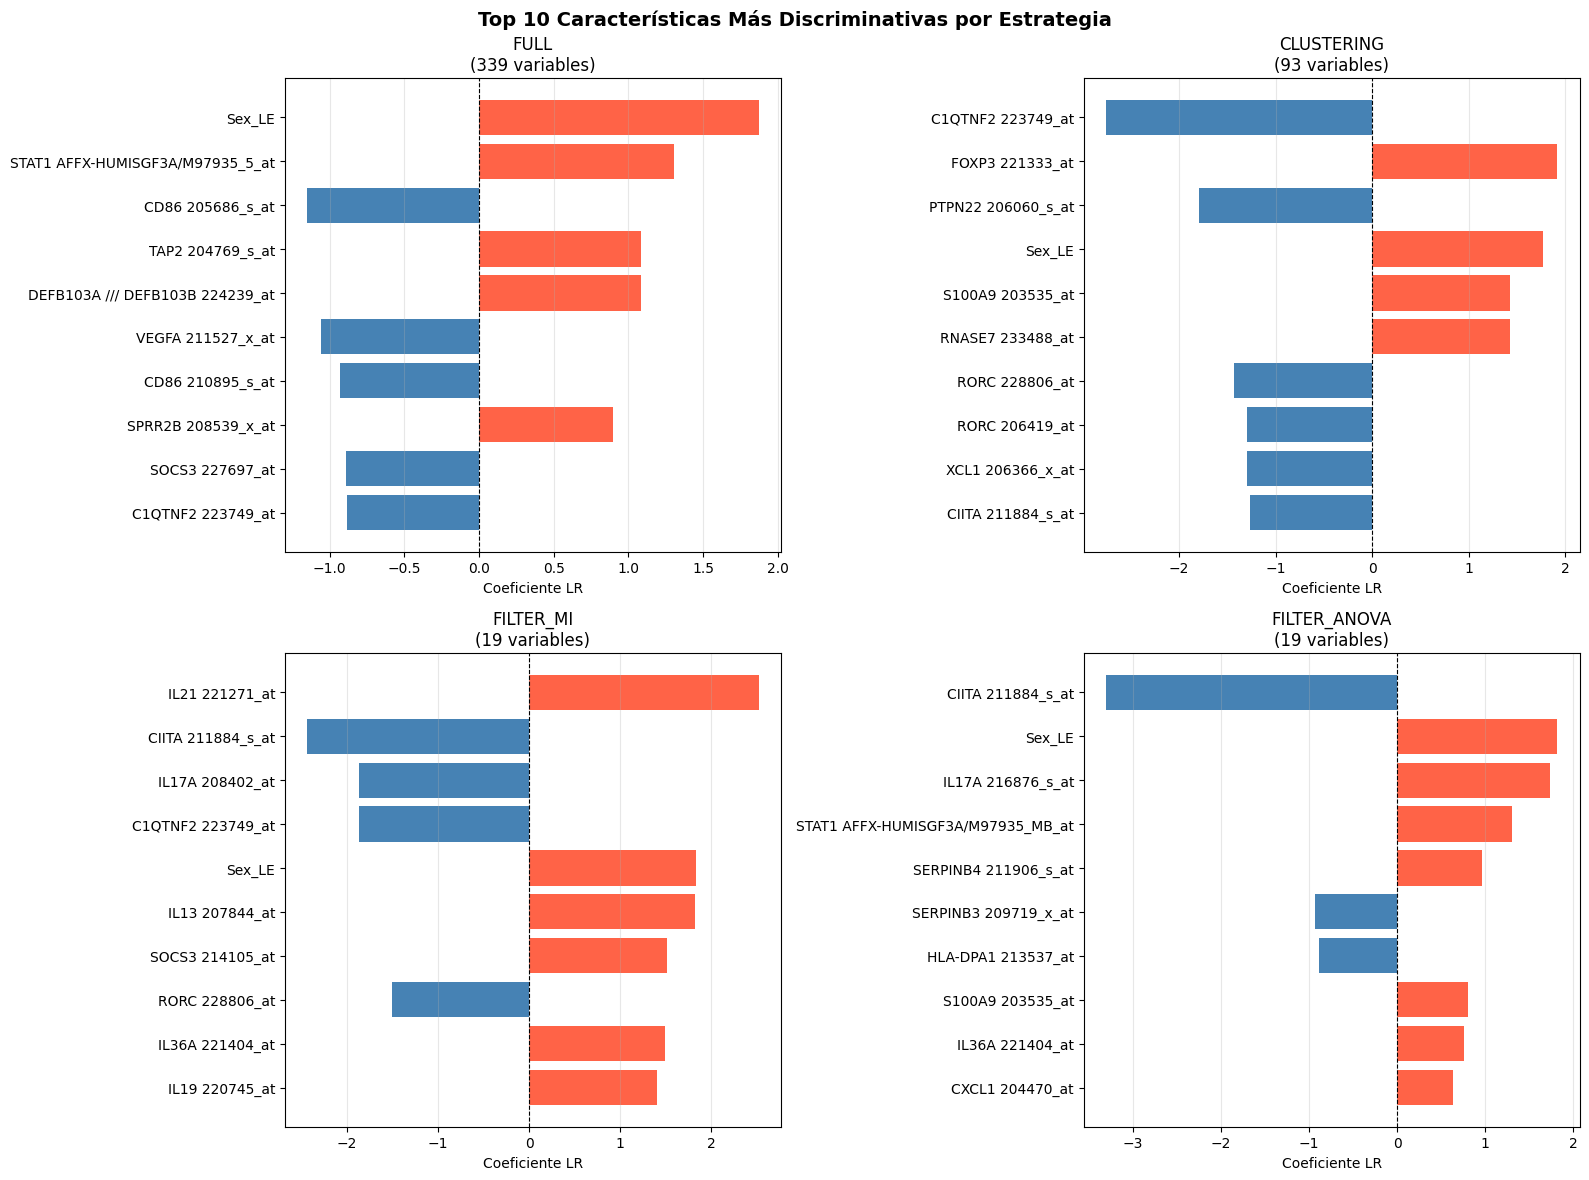

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (nombre, coef_df) in zip(axes, importancias.items()):
    top10 = coef_df.head(10)
    colores = [COLORES[1] if c > 0 else COLORES[0] for c in top10['Coeficiente']]
    ax.barh(top10['Variable'][::-1], top10['Coeficiente'][::-1], color=colores[::-1])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Coeficiente LR')
    ax.set_title(f'{nombre}\n({len(coef_df)} variables)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 Características Más Discriminativas por Estrategia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 21. Métricas de Evaluación

### 21.1 Justificación en el Contexto del Problema
En un problema de detección de enfermedades como la psoriasis, el costo de un **falso negativo** 
(paciente enfermo clasificado como sano) es mayor que el de un **falso positivo**. Por ello, 
la métrica principal debe considerar el desempeño del modelo en ambas clases de forma independiente 
del umbral de decisión y del desbalance moderado (70:30).

Se utilizan las siguientes métricas:

- **AUC-ROC**: mide la capacidad del modelo para separar ambas clases globalmente, sin depender 
  de un umbral específico. Es la métrica principal para comparar estrategias.
- **Recall (Psoriasis)**: mide la proporción de pacientes con psoriasis correctamente identificados. 
  Prioritario dado el costo clínico de los falsos negativos.
- **F1-weighted**: evalúa la calidad de las decisiones al aplicar un umbral de corte, 
  considerando el desbalance de clases.
- **Balanced Accuracy**: complementa el AUC al evaluar el desempeño promedio entre clases 
  con desbalance moderado.

### 21.2 Matrices de Confusión y Reporte de Clasificación

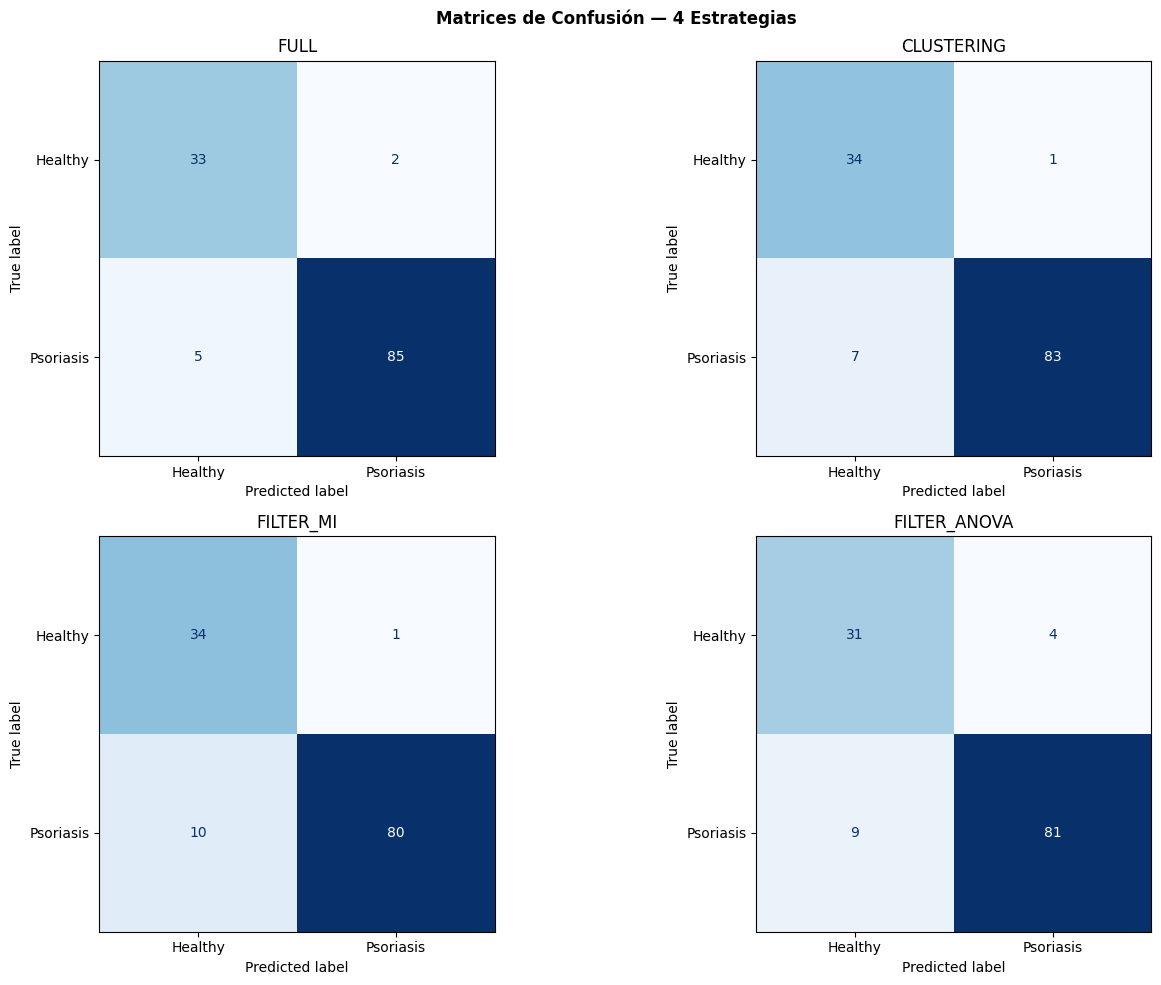


📋 REPORTES DE CLASIFICACIÓN:


═══ FULL ═══
              precision    recall  f1-score   support

     Healthy       0.87      0.94      0.90        35
   Psoriasis       0.98      0.94      0.96        90

    accuracy                           0.94       125
   macro avg       0.92      0.94      0.93       125
weighted avg       0.95      0.94      0.94       125


═══ CLUSTERING ═══
              precision    recall  f1-score   support

     Healthy       0.83      0.97      0.89        35
   Psoriasis       0.99      0.92      0.95        90

    accuracy                           0.94       125
   macro avg       0.91      0.95      0.92       125
weighted avg       0.94      0.94      0.94       125


═══ FILTER_MI ═══
              precision    recall  f1-score   support

     Healthy       0.77      0.97      0.86        35
   Psoriasis       0.99      0.89      0.94        90

    accuracy                           0.91       125
   macro avg       0.88      0.93      0.90 

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, nombre in zip(axes, datasets.keys()):
    _, X_test, _, y_test = splits_finales[nombre]
    y_pred = modelos_finales[nombre].predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=['Healthy', 'Psoriasis'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Psoriasis'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}')

plt.suptitle('Matrices de Confusión — 4 Estrategias', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('matrices_confusion_baseline.png', bbox_inches='tight', dpi=150)
plt.show()

# Reportes de clasificación
print('\n📋 REPORTES DE CLASIFICACIÓN:\n')
for nombre in datasets.keys():
    _, X_test, _, y_test = splits_finales[nombre]
    y_pred = modelos_finales[nombre].predict(X_test)

    print(f'\n═══ {nombre} ═══')
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Psoriasis']))

## 22. Análisis de Sub/Sobreajuste

### 22.1 Comparación de Métricas Entrenamiento vs. Validación

Para determinar si el modelo está sub o sobreajustando, se comparan las métricas obtenidas 
en entrenamiento contra las de validación cruzada (5-fold). 

- **Sobreajuste**: AUC de entrenamiento significativamente mayor que el de validación → 
  el modelo memoriza los datos de entrenamiento.
- **Subajuste**: AUC de entrenamiento y validación ambos bajos → el modelo no captura 
  la señal del problema.
- **Ajuste adecuado**: AUC de entrenamiento y validación similares y altos.
- **Estabilidad**: una desviación estándar alta en el AUC de validación indica que el modelo 
  es sensible a la partición de los datos, lo cual es un factor adicional al elegir la 
  estrategia más robusta.

In [12]:
print('📊 ANÁLISIS DE SUB/SOBREAJUSTE — AUC Entrenamiento vs. Validación:\n')
print(f"{'Estrategia':<15} {'AUC Train':>10} {'AUC Val':>10} {'Std Val':>8} {'Diferencia':>12} {'Diagnóstico'}")
print('-' * 77)

for nombre, r in resultados_baseline.items():
    auc_train = r['AUC_train']
    auc_val   = r['AUC']
    auc_std   = r['AUC_std']
    diff      = auc_train - auc_val

    if diff > 0.05:
        diagnostico = 'Sobreajuste'
    elif auc_train < 0.75 and auc_val < 0.75:
        diagnostico = 'Subajuste'
    else:
        diagnostico = 'Ajuste adecuado'

    print(f'{nombre:<15} {auc_train:>10.3f} {auc_val:>10.3f} {auc_std:>8.3f} {diff:>12.3f}   {diagnostico}')

📊 ANÁLISIS DE SUB/SOBREAJUSTE — AUC Entrenamiento vs. Validación:

Estrategia       AUC Train    AUC Val  Std Val   Diferencia Diagnóstico
-----------------------------------------------------------------------------
FULL                 1.000      0.972    0.010        0.028   Ajuste adecuado
CLUSTERING           0.988      0.944    0.018        0.044   Ajuste adecuado
FILTER_MI            0.935      0.914    0.025        0.021   Ajuste adecuado
FILTER_ANOVA         0.924      0.899    0.019        0.025   Ajuste adecuado


---
## 23. Conclusiones

### 23.1 Selección de Estrategia

Con base en el diagnóstico de 4 casos realizado en la sección 19.3:

- **CASO 1 (FILTER ≈ CLUSTERING ≈ FULL):** Seleccionar **FILTER** — reduce dimensionalidad sin pérdida de desempeño. Mejor para interpretabilidad y generalización.

- **CASO 2 (CLUSTERING ≈ FULL, FILTER peor):** Seleccionar **CLUSTERING** — las variables redundantes aportan información complementaria, pero CLUSTERING ofrece un buen compromiso entre desempeño y dimensionalidad.

- **CASO 3 (FILTER ≈ FULL, CLUSTERING peor):** Seleccionar **FILTER** — el clustering perdió información valiosa, pero FILTER mantiene las variables discriminativas.

- **CASO 4 (FULL mejor que todos):** Seleccionar **FULL** — se requiere toda la información disponible. En siguiente pasos considerar métodos wrapper como RFE (Recursive Feature Elimination) para identificar subconjuntos de variables más discriminativos.

La estabilidad del modelo (desviación estándar del AUC entre folds) es un criterio complementario: una estrategia con AUC alto pero std elevado indica sensibilidad al particionado, lo que reduce la confianza en su desempeño real.

> **Nota:** Independientemente del caso diagnóstico, es recomendable considerar que un AUC de entrenamiento perfecto (1.000) en FULL sugiere memorización de los datos. En validación, CLUSTERING alcanza un desempeño similar a FULL (0.947 vs 0.977) con 93 variables vs 339, lo que lo posiciona como alternativa válida en avances posteriores.


📊 TABLA RESUMEN FINAL:

  Estrategia  Num_Variables      AUC  AUC_std  Balanced_Acc       F1
        FULL            339 0.972105 0.009857      0.928325 0.930480
  CLUSTERING             93 0.943546 0.018330      0.913990 0.906393
   FILTER_MI             19 0.913910 0.024620      0.866981 0.852236
FILTER_ANOVA             19 0.899103 0.018615      0.844562 0.841998


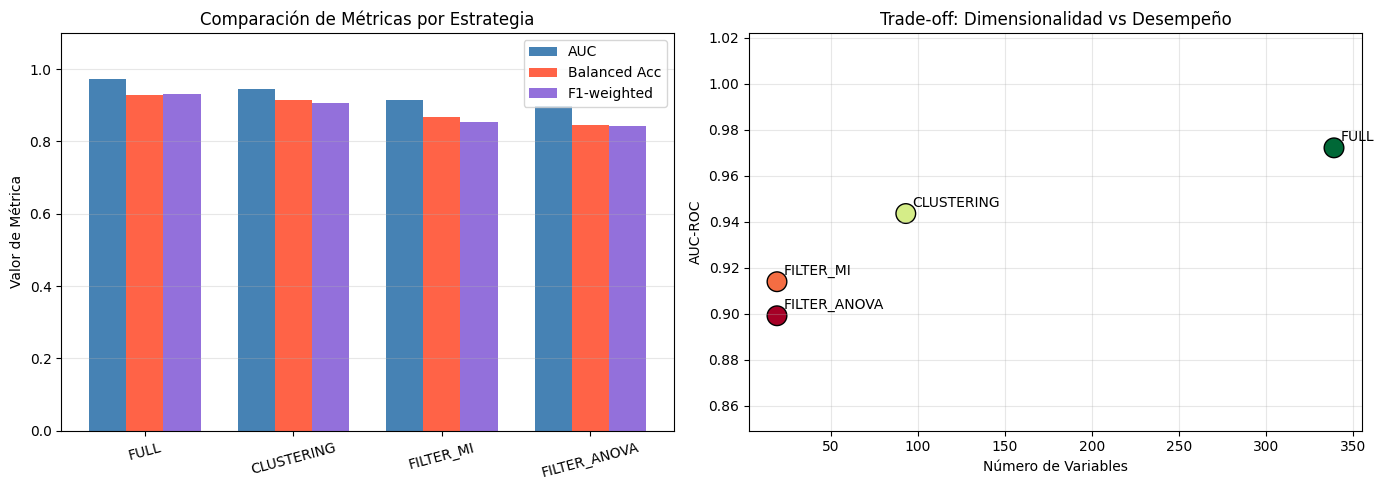

In [13]:
# Tabla resumen
tabla_resumen = pd.DataFrame({
    'Estrategia'   : list(resultados_baseline.keys()),
    'Num_Variables': [datasets[k].shape[1] for k in resultados_baseline.keys()],
    'AUC'          : [r['AUC'] for r in resultados_baseline.values()],
    'AUC_std'      : [r['AUC_std'] for r in resultados_baseline.values()],
    'Balanced_Acc' : [r['Balanced_Acc'] for r in resultados_baseline.values()],
    'F1'           : [r['F1'] for r in resultados_baseline.values()]
}).sort_values('AUC', ascending=False)

print('\n📊 TABLA RESUMEN FINAL:\n')
print(tabla_resumen.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Métricas por estrategia
x     = range(len(tabla_resumen))
width = 0.25
axes[0].bar([i-width for i in x], tabla_resumen['AUC'], width, label='AUC', color='steelblue')
axes[0].bar(x, tabla_resumen['Balanced_Acc'], width, label='Balanced Acc', color='tomato')
axes[0].bar([i+width for i in x], tabla_resumen['F1'], width, label='F1-weighted', color='mediumpurple')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tabla_resumen['Estrategia'], rotation=15)
axes[0].set_ylabel('Valor de Métrica')
axes[0].set_title('Comparación de Métricas por Estrategia')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Panel 2: Trade-off dimensionalidad vs desempeño
# Escala ajustada al rango real de los datos para no amplificar diferencias pequeñas
auc_min = tabla_resumen['AUC'].min()
auc_max = tabla_resumen['AUC'].max()
margen  = 0.05

axes[1].scatter(tabla_resumen['Num_Variables'], tabla_resumen['AUC'],
                s=200, c=tabla_resumen['AUC'], cmap='RdYlGn', edgecolors='black')
for _, row in tabla_resumen.iterrows():
    axes[1].annotate(row['Estrategia'],
                     (row['Num_Variables'], row['AUC']),
                     xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Número de Variables')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim([auc_min - margen, auc_max + margen])
axes[1].set_title('Trade-off: Dimensionalidad vs Desempeño')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Selección automática basada en diagnóstico
auc_full  = resultados_baseline['FULL']['AUC']
auc_clust = resultados_baseline['CLUSTERING']['AUC']
auc_mi    = resultados_baseline['FILTER_MI']['AUC']
auc_anova = resultados_baseline['FILTER_ANOVA']['AUC']
auc_filt  = max(auc_mi, auc_anova)
umbral_similar = 0.02

if abs(auc_filt - auc_clust) < umbral_similar and abs(auc_filt - auc_full) < umbral_similar:
    estrategia_seleccionada = 'FILTER_MI' if auc_mi >= auc_anova else 'FILTER_ANOVA'
    razon = 'CASO 1: Las 4 estrategias tienen desempeño similar. FILTER reduce dimensionalidad sin pérdida.'
elif abs(auc_clust - auc_full) < umbral_similar and auc_filt < auc_clust - umbral_similar:
    estrategia_seleccionada = 'CLUSTERING'
    razon = 'CASO 2: CLUSTERING ≈ FULL, pero FILTER es peor. Las variables redundantes aportan información.'
elif abs(auc_filt - auc_full) < umbral_similar and auc_clust < auc_full - umbral_similar:
    estrategia_seleccionada = 'FILTER_MI' if auc_mi >= auc_anova else 'FILTER_ANOVA'
    razon = 'CASO 3: FILTER ≈ FULL, pero CLUSTERING es peor. El clustering perdió información valiosa.'
elif auc_full > max(auc_clust, auc_filt) + umbral_similar:
    estrategia_seleccionada = 'FULL'
    razon = 'CASO 4: FULL supera a las demás estrategias. Se requiere toda la información disponible.'
else:
    estrategia_seleccionada = tabla_resumen.iloc[0]['Estrategia']
    razon = 'Resultados no concluyentes. Se selecciona la estrategia con mayor AUC.'

print('\n' + '='*70)
print('ESTRATEGIA SELECCIONADA PARA AVANCES SIGUIENTES')
print('='*70)
print(f'\nEstrategia     : {estrategia_seleccionada}')
print(f'Razón          : {razon}')
print(f'Num. Variables : {datasets[estrategia_seleccionada].shape[1]}')
print(f'AUC-ROC        : {resultados_baseline[estrategia_seleccionada]["AUC"]:.4f}')
print(f'AUC_std        : {resultados_baseline[estrategia_seleccionada]["AUC_std"]:.4f}')
print(f'Balanced Acc   : {resultados_baseline[estrategia_seleccionada]["Balanced_Acc"]:.4f}')
print(f'F1-weighted    : {resultados_baseline[estrategia_seleccionada]["F1"]:.4f}')
print('\n' + '='*70)


ESTRATEGIA SELECCIONADA PARA AVANCES SIGUIENTES

Estrategia     : FULL
Razón          : CASO 4: FULL supera a las demás estrategias. Se requiere toda la información disponible.
Num. Variables : 339
AUC-ROC        : 0.9721
AUC_std        : 0.0099
Balanced Acc   : 0.9283
F1-weighted    : 0.9305



### 23.2 Siguientes Pasos (CRISP-ML)

Siguiendo el marco CRISP-ML(Q), los resultados del baseline orientan las siguientes acciones:

- **Modelado**: entrenar modelos más complejos usando el conjunto **FULL** como dataset de referencia establecido en esta fase.
- **Evaluación**: mantener AUC, Recall (Psoriasis) y F1-weighted como métricas principales, priorizando Recall dado el costo clínico de los falsos negativos.
- **Identificación de biomarcadores**: una vez seleccionado el modelo final, aplicar técnicas de interpretabilidad (SHAP, coeficientes) sobre las variables originales del conjunto FULL para identificar los genes más relevantes asociados a psoriasis.